In [46]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import shapiro 
from scipy.stats import pearsonr
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

In [11]:
salinity = xr.open_dataset('../salinity_ts_0.25.nc')['sos_abs']
amplitude = xr.open_dataset('../amplitude_ts_0.25.nc')['tos_con']
salinity['time_counter'] = salinity['time_counter'].dt.year

In [ ]:
## Salinity Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = salinity.shape
sw = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        point = salinity.isel(j=j, i=i)
        if np.isnan(point).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(point['time_counter'], point.values)
        y_hat = intercept + slope * point['time_counter']
        residuals = point.values - y_hat
        sw[j, i] = shapiro(residuals).pvalue
    print(j)


In [7]:
sw_vals = sw[~np.isnan(sw)]



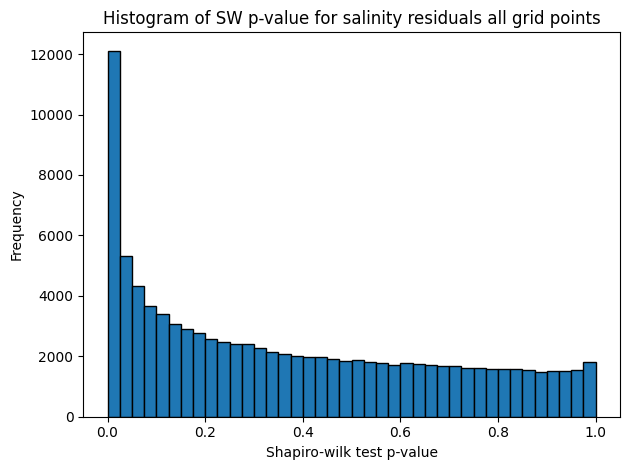

In [8]:
fig, ax = plt.subplots()

ax.hist(sw_vals, bins=40, edgecolor='black')
ax.set_xlabel("Shapiro-wilk test p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of SW p-value for salinity residuals all grid points")

plt.tight_layout()
plt.show()

In [20]:
pval_da = xr.DataArray(data = sw, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of Salinity Residuals'})

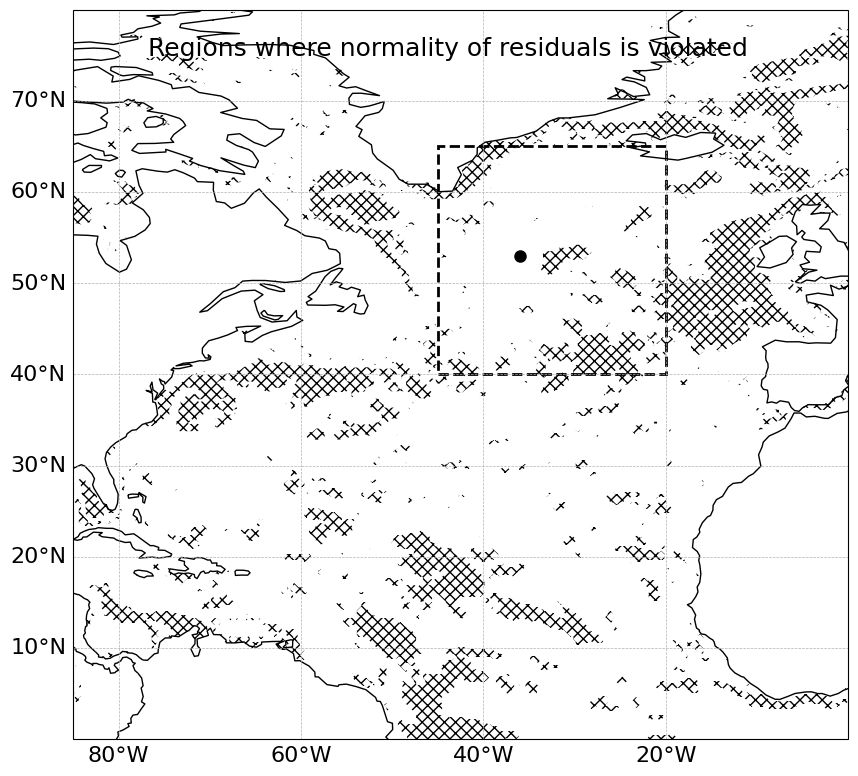

In [22]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())


In [45]:
print((np.sum(sw_vals < 0.05) / sw_vals.size) * 100)

18.02113570860407


In [ ]:
## Amplitude Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = amplitude.shape
sw2 = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        point = amplitude.isel(j=j, i=i)
        if np.isnan(point).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(point['year'], point.values)
        y_hat = intercept + slope * point['year']
        residuals = point.values - y_hat
        sw2[j, i] = shapiro(residuals).pvalue
    print(j)

sw2_vals = sw2[~np.isnan(sw2)]


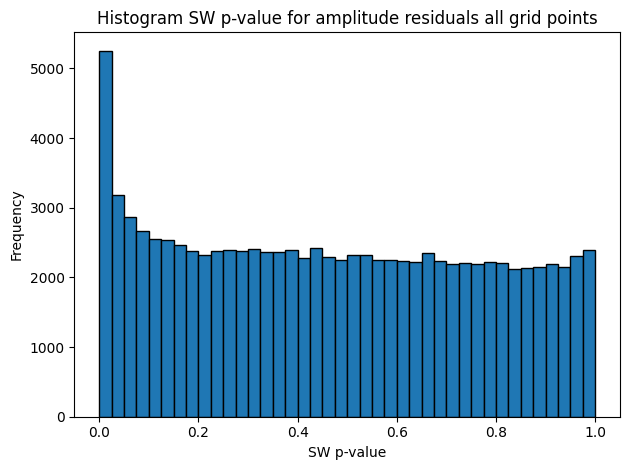

In [23]:
fig, ax = plt.subplots()

ax.hist(sw2_vals, bins=40, edgecolor='black')
ax.set_xlabel("SW p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram SW p-value for amplitude residuals all grid points")

plt.tight_layout()
plt.show()

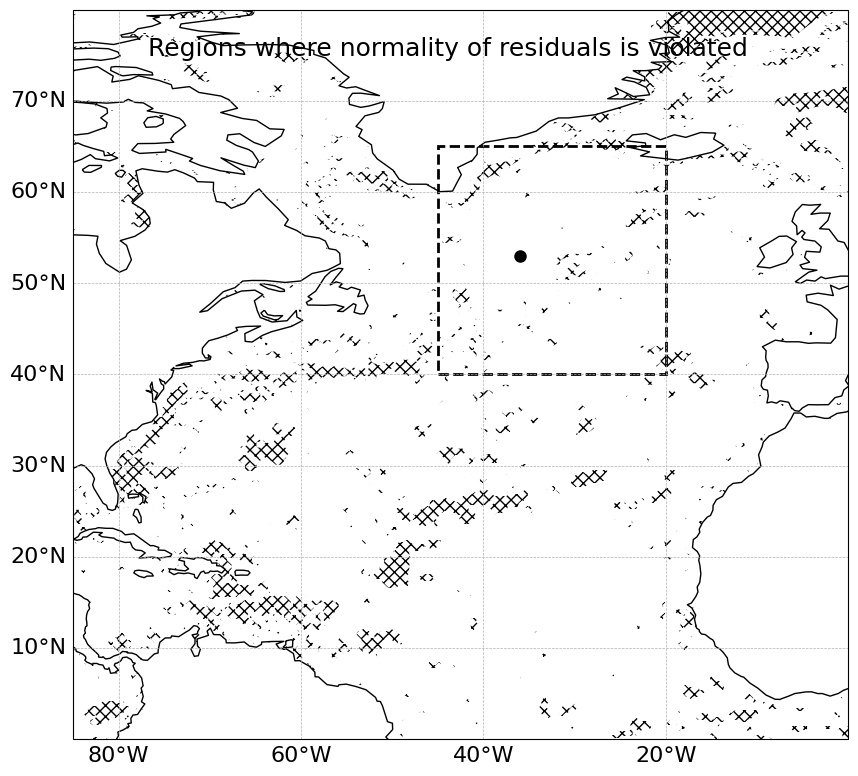

In [24]:
## Hatched Plot 
pval_da = xr.DataArray(data = sw2, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of Amplitude Residuals'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())


In [44]:
print((np.sum(sw2_vals < 0.05) / sw2_vals.size) * 100)

8.719771081474747


In [ ]:
## Regression Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = salinity.shape
sw3 = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        sal_ts = salinity.isel(j=j, i=i).values
        amp_ts = amplitude.isel(j=j, i=i).values
        if np.isnan(sal_ts).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(sal_ts, amp_ts) 
        y_hat = intercept + slope * sal_ts
        residuals = amp_ts - y_hat
        sw3[j, i] = shapiro(residuals).pvalue
    print(j)

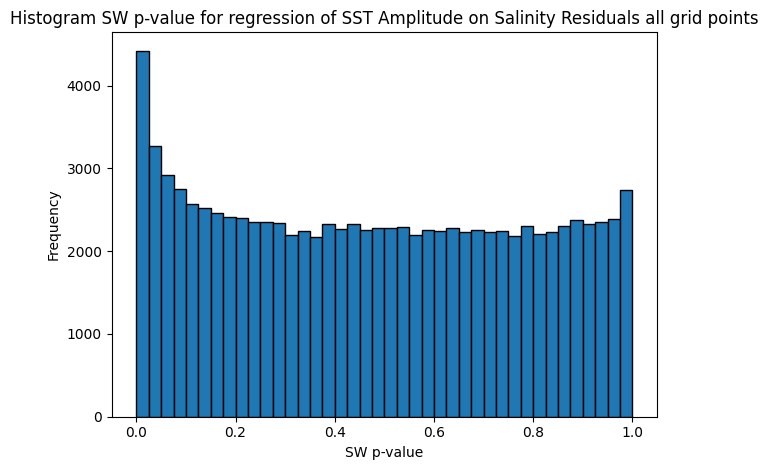

7.95016683367251


In [42]:
sw3_vals = sw3[~np.isnan(sw3)]

fig, ax = plt.subplots()

ax.hist(sw3_vals, bins=40, edgecolor='black')
ax.set_xlabel("SW p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram SW p-value for regression of SST Amplitude on Salinity Residuals all grid points")

plt.tight_layout()
plt.show()


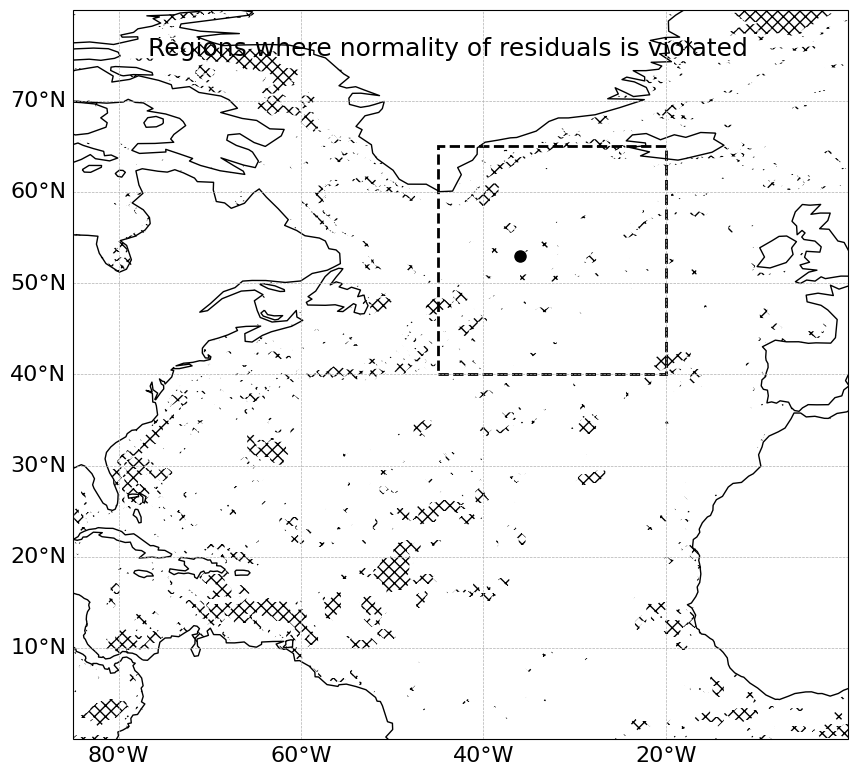

In [37]:
## Hatched Plot 

pval_da = xr.DataArray(data = sw3, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of regression of SST Amplitude on Salinity Residuals'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

In [43]:
print((np.sum(sw3_vals < 0.05) / sw3_vals.size) * 100)

7.95016683367251


In [47]:
## What about salinity when using GLSAR? 

nyears, nj, ni = salinity.shape
sw = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        point = salinity.isel(j=j, i=i)
        if np.isnan(point).all():
            continue
        Y = point.values
        X = sm.add_constant(point['time_counter'].values)
        model = sm.GLSAR(Y, X, 1)
        results = model.iterative_fit(maxiter=50)
        sw[j, i] = shapiro(results.resid).pvalue
    print(j)

sw_vals = sw[~np.isnan(sw)]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

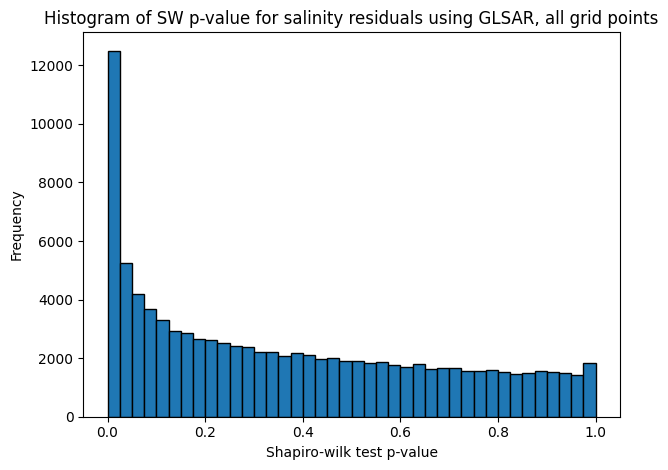

In [48]:
fig, ax = plt.subplots()

ax.hist(sw_vals, bins=40, edgecolor='black')
ax.set_xlabel("Shapiro-wilk test p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of SW p-value for salinity residuals using GLSAR, all grid points")

plt.tight_layout()
plt.show()

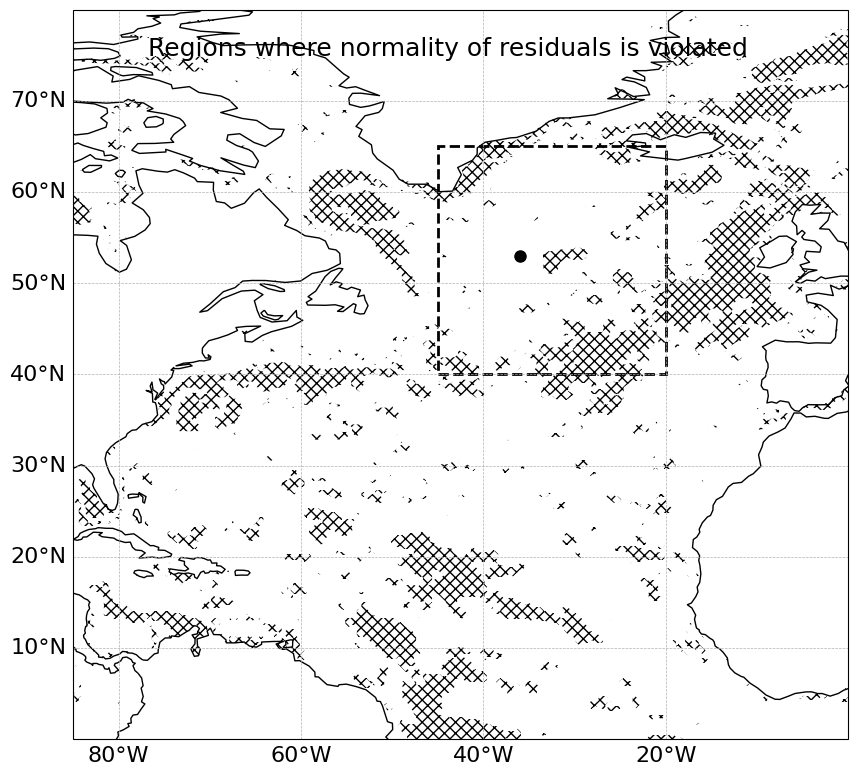

In [49]:
## Hatched Plot 

pval_da = xr.DataArray(data = sw, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of Salinity Residuals using GLSAR'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())


In [50]:
print((np.sum(sw_vals < 0.05) / sw_vals.size) * 100)

18.348604898608514
